<a href="https://colab.research.google.com/github/iisratislam/Generative_Modeling_Case-Study/blob/main/part2_quickdraw_gan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GAN Case Study — Part 2.3: Birthday Cake Sketches with a DCGAN

We train a **Deep Convolutional GAN (DCGAN)** to generate synthetic birthday
cake sketches from Google's **QuickDraw** dataset. QuickDraw provides
pre-rendered 28×28 grayscale bitmaps, so the data format matches OCTMNIST and
we can reuse the same DCGAN architecture.

In [1]:
%matplotlib inline
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Download the pre-rendered 28x28 bitmap version of the 'birthday cake' category.
# Google hosts QuickDraw .npy bitmaps on Google Cloud Storage.
!wget -q "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/birthday%20cake.npy" -O birthday_cake.npy

# Load it
cakes = np.load("birthday_cake.npy")   # shape: (N, 784), uint8, values 0-255
print("Raw shape:", cakes.shape)

Using device: cuda
Raw shape: (144982, 784)


## 1. Explore the birthday cake sketches

Each sketch is a flattened 28×28 grayscale bitmap. We reshape the data into
image form, take a manageable subset for training (the full set is very
large), and visualise a sample of real sketches to see what the DCGAN must
reproduce.

Working subset shape: (20000, 28, 28)
Pixel value range: 0 to 255


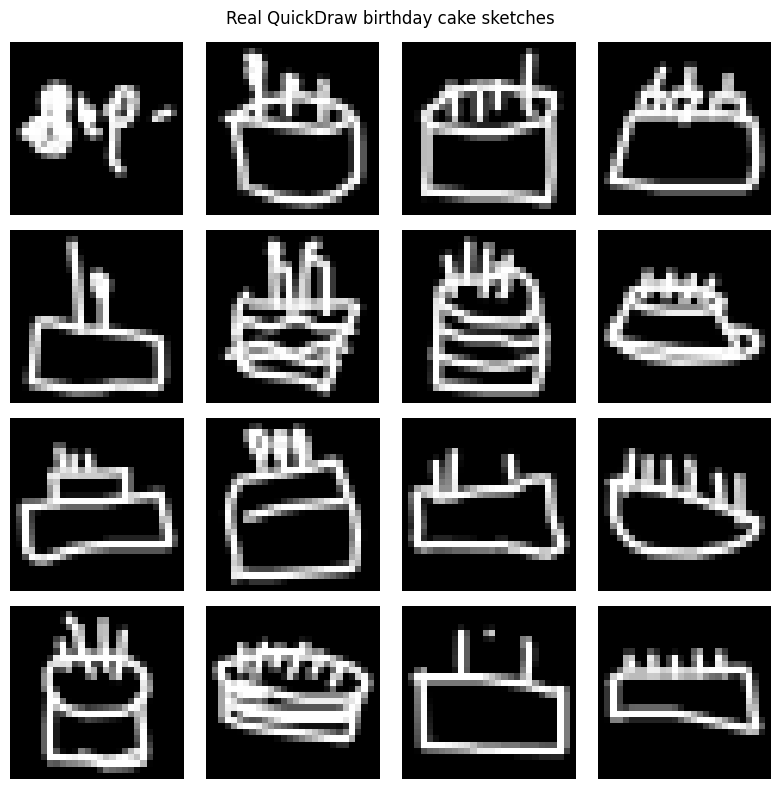

In [2]:
# Reshape flattened rows into 28x28 images
cakes_imgs = cakes.reshape(-1, 28, 28)

# The full dataset is very large; take a random subset for faster training
SUBSET_SIZE = 20000
rng = np.random.default_rng(0)
idx = rng.choice(cakes_imgs.shape[0], size=SUBSET_SIZE, replace=False)
cake_subset = cakes_imgs[idx]

print("Working subset shape:", cake_subset.shape)
print("Pixel value range:", cake_subset.min(), "to", cake_subset.max())


def show_image_grid(images, n=16, title="Sample sketches"):
    """Displays the first n images in a 4-column grid."""
    cols = 4
    rows = (n + cols - 1) // cols
    plt.figure(figsize=(8, 2 * rows))
    for i in range(n):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[i], cmap="gray")
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


show_image_grid(cake_subset, n=16, title="Real QuickDraw birthday cake sketches")

## 2. Prepare the data for DCGAN training

As with OCTMNIST, we normalise the sketches to **[-1, 1]** (to match the
generator's Tanh output), add a channel dimension, and wrap them in a
`DataLoader` for batched training.

In [3]:
from torch.utils.data import TensorDataset, DataLoader

def prepare_dataloader(images, batch_size=128):
    """
    Normalises images to [-1, 1], adds a channel dimension, and returns a
    DataLoader for batched training.

    Args:
        images: numpy array of shape (N, 28, 28), values 0-255
        batch_size: training batch size

    Returns:
        DataLoader yielding batches of shape (B, 1, 28, 28).
    """
    imgs = images.astype(np.float32) / 127.5 - 1.0   # 0-255 -> [-1, 1]
    imgs = torch.from_numpy(imgs).unsqueeze(1)        # (N, 28, 28) -> (N, 1, 28, 28)

    dataset = TensorDataset(imgs)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    return loader


BATCH_SIZE = 128
train_loader = prepare_dataloader(cake_subset, batch_size=BATCH_SIZE)

# Sanity check on one batch
batch = next(iter(train_loader))[0]
print("Batch shape:", batch.shape)
print("Batch value range:", batch.min().item(), "to", batch.max().item())

Batch shape: torch.Size([128, 1, 28, 28])
Batch value range: -1.0 to 1.0


## 3. Build the DCGAN

We reuse the same DCGAN architecture as Part 2.1, since both datasets are
28×28 grayscale:

- **Generator**: upsamples a noise vector via transposed convolutions
  (1×1 → 7×7 → 14×14 → 28×28), with BatchNorm + ReLU and a Tanh output.
- **Discriminator**: a CNN that downsamples the image through strided
  convolutions to a single real/fake logit, using LeakyReLU.

In [4]:
class Generator(nn.Module):
    """
    DCGAN generator: maps a noise vector to a 1x28x28 image via transposed
    convolutions. BatchNorm + ReLU between layers; Tanh output for [-1, 1].
    """
    def __init__(self, noise_dim=100, feature_maps=64):
        super().__init__()
        self.noise_dim = noise_dim
        self.net = nn.Sequential(
            # (noise_dim, 1, 1) -> (fm*4, 7, 7)
            nn.ConvTranspose2d(noise_dim, feature_maps * 4, kernel_size=7,
                               stride=1, padding=0, bias=False),
            nn.BatchNorm2d(feature_maps * 4),
            nn.ReLU(True),
            # (fm*4, 7, 7) -> (fm*2, 14, 14)
            nn.ConvTranspose2d(feature_maps * 4, feature_maps * 2, kernel_size=4,
                               stride=2, padding=1, bias=False),
            nn.BatchNorm2d(feature_maps * 2),
            nn.ReLU(True),
            # (fm*2, 14, 14) -> (1, 28, 28)
            nn.ConvTranspose2d(feature_maps * 2, 1, kernel_size=4,
                               stride=2, padding=1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        z = z.view(z.size(0), self.noise_dim, 1, 1)
        return self.net(z)


class Discriminator(nn.Module):
    """
    DCGAN discriminator: a CNN that downsamples a 1x28x28 image through strided
    convolutions to a single logit. LeakyReLU + BatchNorm; no sigmoid.
    """
    def __init__(self, feature_maps=64):
        super().__init__()
        self.net = nn.Sequential(
            # (1, 28, 28) -> (fm, 14, 14)
            nn.Conv2d(1, feature_maps, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # (fm, 14, 14) -> (fm*2, 7, 7)
            nn.Conv2d(feature_maps, feature_maps * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(feature_maps * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # (fm*2, 7, 7) -> (1, 1, 1)
            nn.Conv2d(feature_maps * 2, 1, kernel_size=7, stride=1, padding=0, bias=False),
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)

## 4. Weight initialisation and model creation

We apply the DCGAN-recommended weight initialisation (Normal(0, 0.02)) and
create the generator and discriminator, then run a quick shape check to confirm
the two networks connect correctly.

In [5]:
def weights_init(m):
    """
    DCGAN weight initialisation (Radford et al., 2016):
    - Conv/ConvTranspose weights ~ Normal(0, 0.02)
    - BatchNorm weights ~ Normal(1, 0.02), biases = 0
    """
    classname = m.__class__.__name__
    if "Conv" in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


NOISE_DIM = 100

gen = Generator(noise_dim=NOISE_DIM, feature_maps=64).to(device)
disc = Discriminator(feature_maps=64).to(device)

gen.apply(weights_init)
disc.apply(weights_init)

# Shape check: generate a batch and pass it through the discriminator
z = torch.randn(8, NOISE_DIM, device=device)
fake = gen(z)
print("Generator output shape:", fake.shape)     # expect (8, 1, 28, 28)
print("Discriminator output shape:", disc(fake).shape)  # expect (8, 1)

Generator output shape: torch.Size([8, 1, 28, 28])
Discriminator output shape: torch.Size([8, 1])


## 5. Train the DCGAN

Same training procedure as Part 2.1: standard GAN objective with
`BCEWithLogitsLoss`, Adam (lr = 0.0002, betas = (0.5, 0.999)). We track losses
and snapshot a fixed noise batch each epoch to watch the sketches sharpen.

In [6]:
def train_dcgan(gen, disc, dataloader, noise_dim=100,
                n_epochs=30, lr=2e-4, log_every=1):
    """
    Trains a DCGAN with the standard GAN objective (BCEWithLogitsLoss).
    Tracks generator/discriminator losses and snapshots a fixed noise batch
    each epoch so we can watch sketch quality improve.

    Returns (g_losses, d_losses, snapshots).
    """
    criterion = nn.BCEWithLogitsLoss()
    opt_g = torch.optim.Adam(gen.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(disc.parameters(), lr=lr, betas=(0.5, 0.999))

    fixed_noise = torch.randn(16, noise_dim, device=device)
    g_losses, d_losses, snapshots = [], [], []

    for epoch in range(n_epochs):
        epoch_g, epoch_d, n_batches = 0.0, 0.0, 0

        for (real_imgs,) in dataloader:
            real_imgs = real_imgs.to(device)
            b_size = real_imgs.size(0)

            real_labels = torch.ones(b_size, 1, device=device)
            fake_labels = torch.zeros(b_size, 1, device=device)

            # ---- Train Discriminator ----
            z = torch.randn(b_size, noise_dim, device=device)
            fake_imgs = gen(z)

            d_real = criterion(disc(real_imgs), real_labels)
            d_fake = criterion(disc(fake_imgs.detach()), fake_labels)
            d_loss = d_real + d_fake

            opt_d.zero_grad()
            d_loss.backward()
            opt_d.step()

            # ---- Train Generator ----
            g_loss = criterion(disc(fake_imgs), real_labels)

            opt_g.zero_grad()
            g_loss.backward()
            opt_g.step()

            epoch_g += g_loss.item()
            epoch_d += d_loss.item()
            n_batches += 1

        g_losses.append(epoch_g / n_batches)
        d_losses.append(epoch_d / n_batches)

        gen.eval()
        with torch.no_grad():
            snapshots.append(gen(fixed_noise).cpu())
        gen.train()

        if (epoch + 1) % log_every == 0:
            print(f"Epoch {epoch+1}/{n_epochs} | D loss: {d_losses[-1]:.4f} "
                  f"| G loss: {g_losses[-1]:.4f}")

    return g_losses, d_losses, snapshots

In [7]:
N_EPOCHS = 30

g_losses, d_losses, snapshots = train_dcgan(
    gen, disc, train_loader, noise_dim=NOISE_DIM, n_epochs=N_EPOCHS
)

print("Training complete.")

Epoch 1/30 | D loss: 0.8365 | G loss: 1.6919
Epoch 2/30 | D loss: 0.3416 | G loss: 2.1877
Epoch 3/30 | D loss: 0.2890 | G loss: 2.5144
Epoch 4/30 | D loss: 0.3047 | G loss: 2.6567
Epoch 5/30 | D loss: 0.3170 | G loss: 2.7198
Epoch 6/30 | D loss: 0.4553 | G loss: 2.6759
Epoch 7/30 | D loss: 0.4453 | G loss: 2.4132
Epoch 8/30 | D loss: 0.2327 | G loss: 2.7915
Epoch 9/30 | D loss: 0.5405 | G loss: 2.5828
Epoch 10/30 | D loss: 0.3207 | G loss: 2.7064
Epoch 11/30 | D loss: 0.2783 | G loss: 3.1789
Epoch 12/30 | D loss: 0.2685 | G loss: 2.8517
Epoch 13/30 | D loss: 0.4905 | G loss: 2.7383
Epoch 14/30 | D loss: 0.1530 | G loss: 3.3397
Epoch 15/30 | D loss: 0.2930 | G loss: 3.1551
Epoch 16/30 | D loss: 0.5149 | G loss: 2.7877
Epoch 17/30 | D loss: 0.2279 | G loss: 2.9295
Epoch 18/30 | D loss: 0.1554 | G loss: 3.4181
Epoch 19/30 | D loss: 0.4313 | G loss: 2.8447
Epoch 20/30 | D loss: 0.3394 | G loss: 3.2839
Epoch 21/30 | D loss: 0.1822 | G loss: 3.1286
Epoch 22/30 | D loss: 0.3117 | G loss: 3.26

## 6. Training results: loss curves and generated sketches

We plot the loss curves and the generated sketches from the final epoch, then
examine how they evolved across training.

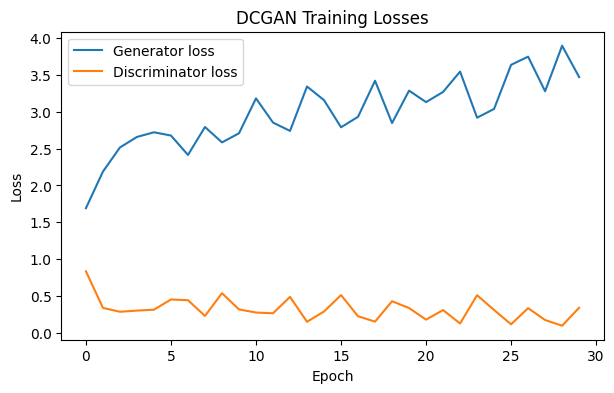

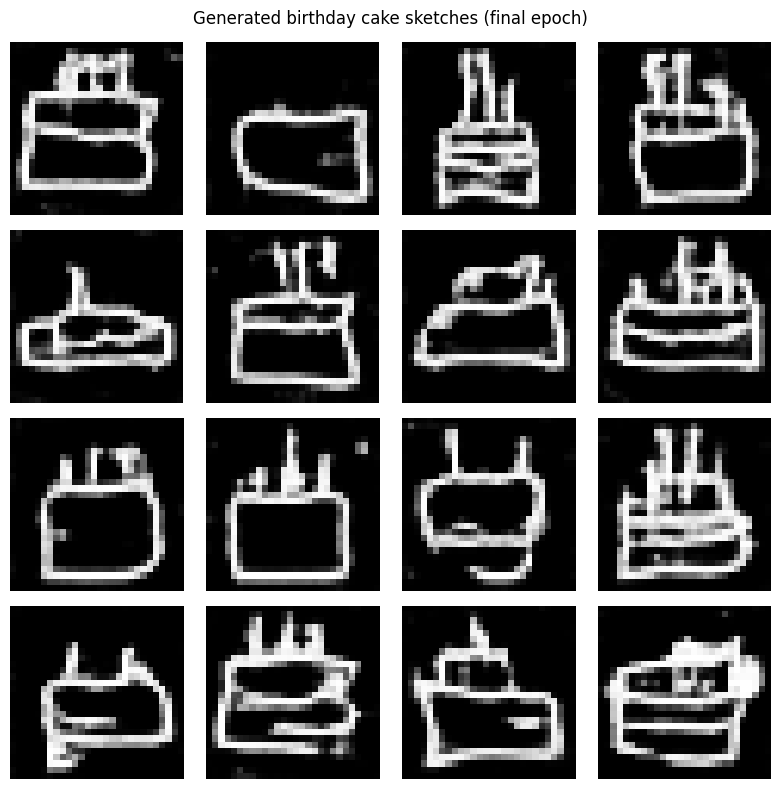

In [8]:
def plot_dcgan_losses(g_losses, d_losses, title="DCGAN Training Losses"):
    """Plots generator and discriminator loss curves per epoch."""
    plt.figure(figsize=(7, 4))
    plt.plot(g_losses, label="Generator loss")
    plt.plot(d_losses, label="Discriminator loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title(title); plt.legend()
    plt.show()


def show_generated_grid(snapshot, n=16, title="Generated sketches"):
    """
    Displays a grid of generated images from a snapshot tensor
    (N, 1, 28, 28). Rescales values from [-1, 1] back to [0, 1].
    """
    imgs = (snapshot + 1) / 2.0
    cols = 4
    rows = (n + cols - 1) // cols
    plt.figure(figsize=(8, 2 * rows))
    for i in range(n):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(imgs[i, 0], cmap="gray")
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


plot_dcgan_losses(g_losses, d_losses)
show_generated_grid(snapshots[-1], n=16, title="Generated birthday cake sketches (final epoch)")

## 7. How generated sketches evolved across training

Using the fixed noise batch saved each epoch, we show the same latent point
developing from early scribbles into a recognisable cake across training.

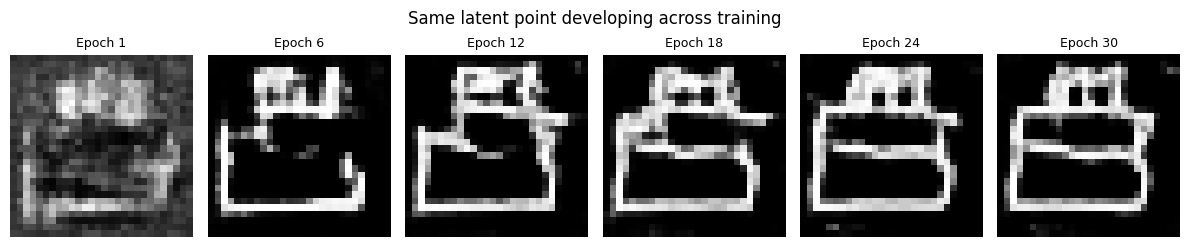

In [9]:
def show_evolution(snapshots, epochs_to_show=None, img_index=0):
    """
    Shows how a single fixed latent point's generated sketch evolved across
    training, displayed at a few evenly-spaced epochs.

    Args:
        snapshots:       list of (16, 1, 28, 28) tensors, one per epoch
        epochs_to_show:  epoch indices to display (default: 6 evenly spaced)
        img_index:       which of the 16 fixed samples to track (0-15)
    """
    n_epochs = len(snapshots)
    if epochs_to_show is None:
        epochs_to_show = np.linspace(0, n_epochs - 1, 6, dtype=int)

    plt.figure(figsize=(12, 2.5))
    for i, ep in enumerate(epochs_to_show):
        img = (snapshots[ep][img_index, 0] + 1) / 2.0  # [-1,1] -> [0,1]
        plt.subplot(1, len(epochs_to_show), i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(f"Epoch {ep + 1}", fontsize=9)
        plt.axis("off")
    plt.suptitle("Same latent point developing across training")
    plt.tight_layout()
    plt.show()


show_evolution(snapshots, img_index=0)

## 8. Quantitative evaluation: Fréchet Inception Distance (FID)

As in Part 2.1, we compute FID between real and generated sketches using the
standard `pytorch-fid` implementation (lower = generated images are closer to
the real distribution). We save equal-sized sets of real and generated images
to disk, and the library handles resizing and grayscale→RGB conversion.

In [10]:
!pip install pytorch-fid -q

import os
from torchvision.utils import save_image

def save_images_for_fid(tensor_imgs, folder, prefix="img"):
    """Saves images (values in [-1, 1], shape (N,1,28,28)) as PNGs into folder."""
    os.makedirs(folder, exist_ok=True)
    imgs = (tensor_imgs + 1) / 2.0  # [-1,1] -> [0,1]
    for i in range(imgs.size(0)):
        save_image(imgs[i], os.path.join(folder, f"{prefix}_{i}.png"))


N_FID = 1000

# ---- Real sketches ----
real_subset = cake_subset[:N_FID].astype(np.float32) / 127.5 - 1.0
real_tensor = torch.from_numpy(real_subset).unsqueeze(1)
save_images_for_fid(real_tensor, "fid_real", prefix="real")

# ---- Generated sketches ----
gen.eval()
with torch.no_grad():
    z = torch.randn(N_FID, NOISE_DIM, device=device)
    fake_tensor = gen(z).cpu()
gen.train()
save_images_for_fid(fake_tensor, "fid_fake", prefix="fake")

print(f"Saved {N_FID} real and {N_FID} generated sketches.")

Saved 1000 real and 1000 generated sketches.


In [11]:
# Compute FID between real and generated sketch folders.
!python -m pytorch_fid fid_real fid_fake --device cuda

Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/pt_inception-2015-12-05-6726825d.pth
100% 91.2M/91.2M [00:00<00:00, 115MB/s]
100% 20/20 [00:04<00:00,  4.73it/s]
100% 20/20 [00:03<00:00,  5.17it/s]
FID:  39.09211601676219
